
## Beauty-Budget Discovery Engine
By: Saanvi Koti

Finds high value alternatives for Beauty products for budget conscious consumers across Sephora

Dataset: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews 



##  1. Install/Import Libraries

In [4]:
# Uncomment if running for the first time:
 # !pip install pandas numpy matplotlib seaborn sqlalchemy openpyxl
 
import warnings
warnings.filterwarnings('ignore')
 
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
 
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
 
# Project-level constants
XLSX_PATH        = 'Cleaned_Sephora_Products.csv' # Changed from .xlsx to .csv
SYNONYMS_PATH    = 'chemical_synonyms.csv'       # ← external CSV, not hardcoded
LUXURY_THRESHOLD = 60    # Products >= $60 → "Luxury"
BUDGET_THRESHOLD = 30    # Products <  $30 → "Budget"
DUPE_SIM_CUTOFF  = 0.60  # Jaccard similarity >= 0.60 required for batch dupes
BUDGET_RATIO_MAX = 0.30  # Budget price must be <= 30% of luxury price
FOCUS_CATEGORIES = ['Skincare', 'Makeup', 'Hair', 'Bath & Body']
 
CATEGORY_PALETTE = {
    'Skincare':    '#E07B8A',
    'Makeup':      '#C36A9D',
    'Hair':        '#7B9DD4',
    'Bath & Body': '#6BBF8E',
    'Fragrance':   '#E8A85A',
    'Mini Size':   '#A3A3A3',
    'Men':         '#708090',
}
 
print('=' * 60)
print('  BEAUTY-BUDGET DISCOVERY ENGINE')
print('=' * 60)
print(f'  Luxury threshold  : >= ${LUXURY_THRESHOLD}')
print(f'  Budget threshold  : <  ${BUDGET_THRESHOLD}')
print(f'  Dupe sim. cutoff  : >= {DUPE_SIM_CUTOFF}')
print(f'  Budget ratio max  : <= {BUDGET_RATIO_MAX * 100:.0f}% of luxury price')
print('  Libraries loaded successfully.')

  BEAUTY-BUDGET DISCOVERY ENGINE
  Luxury threshold  : >= $60
  Budget threshold  : <  $30
  Dupe sim. cutoff  : >= 0.6
  Budget ratio max  : <= 30% of luxury price
  Libraries loaded successfully.


## 2. Load Dataset + Chemical Synonyms

In [5]:
# --- 2a. Sephora product dataset ---
if not os.path.exists(XLSX_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{XLSX_PATH}'.\n"
        "Please ensure 'Cleaned_Sephora_Products.csv' is in the working directory." # Updated filename in error message
    )
 
df_raw = pd.read_csv(XLSX_PATH) # Changed to pd.read_csv and removed engine
print(f'\n[DATA] Sephora Products loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print('       Columns:', df_raw.columns.tolist())
print('\n       First 3 rows:')
print(df_raw[['product_id', 'product_name', 'brand_name',
              'price_usd', 'rating', 'primary_category']].head(3).to_string(index=False))
print('\n       Missing values per column:')
print(df_raw.isnull().sum().to_string())
 
# --- 2b. Chemical Synonyms CSV ---
if not os.path.exists(SYNONYMS_PATH):
    raise FileNotFoundError(
        f"Synonym dataset not found at '{SYNONYMS_PATH}'.\n"
        "Please ensure 'chemical_synonyms.csv' is in the working directory."
    )
 
synonyms_df = pd.read_csv(SYNONYMS_PATH, dtype=str, sep=',', on_bad_lines='skip')
synonyms_df.columns = synonyms_df.columns.str.strip()
synonyms_df['raw_name']       = synonyms_df['raw_name'].str.strip().str.lower()
synonyms_df['canonical_name'] = synonyms_df['canonical_name'].str.strip().str.lower()
synonyms_df = synonyms_df.dropna(subset=['raw_name', 'canonical_name'])
synonyms_df = synonyms_df.drop_duplicates(subset='raw_name')  # keep first mapping per token
 
# Convert to dict for O(1) lookup
CHEMICAL_DICTIONARY = dict(zip(synonyms_df['raw_name'], synonyms_df['canonical_name']))
 
print(f'\n[SYNONYMS] chemical_synonyms.csv loaded:')
print(f'           Rows in CSV        : {len(synonyms_df):,}')
print(f'           Unique raw names   : {synonyms_df["raw_name"].nunique():,}')
print(f'           Unique canonical   : {synonyms_df["canonical_name"].nunique():,}')
print(f'           Dictionary entries : {len(CHEMICAL_DICTIONARY):,}')
print('\n  Sample mappings (first 10):')
for raw, canon in list(CHEMICAL_DICTIONARY.items())[:10]:
    print(f'    "{raw}"  ->  "{canon}"')


[DATA] Sephora Products loaded: 7,519 rows x 8 columns
       Columns: ['product_id', 'product_name', 'brand_name', 'price_usd', 'rating', 'primary_category', 'ingredients', 'cleaned_ingredients']

       First 3 rows:
product_id              product_name brand_name  price_usd  rating primary_category
   P473671   Fragrance Discovery Set      19-69       35.0  3.6364        Fragrance
   P473668   La Habana Eau de Parfum      19-69      195.0  4.1538        Fragrance
   P473662 Rainbow Bar Eau de Parfum      19-69      195.0  4.2500        Fragrance

       Missing values per column:
product_id               0
product_name             0
brand_name               0
price_usd                0
rating                 220
primary_category         0
ingredients              0
cleaned_ingredients      0

[SYNONYMS] chemical_synonyms.csv loaded:
           Rows in CSV        : 355
           Unique raw names   : 355
           Unique canonical   : 247
           Dictionary entries : 355

  Samp

## 3. Data Cleaning & Preprocessing 

In [6]:
df = df_raw.copy()
 
# --- Step 1: Strip whitespace from all string columns ---
str_cols = df.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    df[col] = df[col].str.strip()
print(f'\nStep 1 -- Stripped whitespace from {len(str_cols)} string columns.')
 
# --- Step 2: Standardise category labels with .str.title() ---
df['primary_category'] = df['primary_category'].str.title()
print(f'Step 2 -- Standardised {df["primary_category"].nunique()} unique categories.')
 
# --- Step 3: Drop rows missing critical fields ---
critical_cols = ['product_id', 'product_name', 'brand_name', 'price_usd', 'primary_category']
before = len(df)
df.dropna(subset=critical_cols, inplace=True)
print(f'Step 3 -- Dropped {before - len(df):,} rows with missing critical fields.')
 
# --- Step 4: Remove duplicate product_id entries ---
before = len(df)
df.drop_duplicates(subset='product_id', inplace=True)
print(f'Step 4 -- Dropped {before - len(df):,} duplicate product_id rows.')
 
# --- Step 5: Ensure price_usd is numeric and positive ---
df['price_usd'] = pd.to_numeric(df['price_usd'], errors='coerce')
before = len(df)
df.dropna(subset=['price_usd'], inplace=True)
df = df[df['price_usd'] > 0]
print(f'Step 5 -- After price sanity filter: {len(df):,} rows (removed {before - len(df):,}).')
 
# --- Step 6: Clip price outliers at 99th percentile ---
cap_price = df['price_usd'].quantile(0.99)
df.loc[df['price_usd'] > cap_price, 'price_usd'] = cap_price
print(f'Step 6 -- Prices capped at 99th percentile: ${cap_price:.2f}')
 
# --- Step 7: Coerce rating to numeric; fill NaN with category median ---
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
for cat in df['primary_category'].unique():
    mask   = df['primary_category'] == cat
    median = df.loc[mask, 'rating'].median()
    df.loc[mask & df['rating'].isna(), 'rating'] = median
df['rating'] = df['rating'].fillna(df['rating'].median())
print('Step 7 -- Rating NaN values filled with category medians.')
 
# --- Step 8: Filter to focus categories for ingredient analysis ---
df_focus = df[df['primary_category'].isin(FOCUS_CATEGORIES)].copy()
print(f'Step 8 -- Focus-category subset: {len(df_focus):,} rows '
      f'({", ".join(FOCUS_CATEGORIES)}).')
 
print(f'\n  Final cleaned shape (all)   : {df.shape}')
print(f'  Final cleaned shape (focus) : {df_focus.shape}')
print('\n  Post-cleaning category distribution:')
print(df['primary_category'].value_counts().to_string())


Step 1 -- Stripped whitespace from 6 string columns.
Step 2 -- Standardised 8 unique categories.
Step 3 -- Dropped 0 rows with missing critical fields.
Step 4 -- Dropped 0 duplicate product_id rows.
Step 5 -- After price sanity filter: 7,519 rows (removed 0).
Step 6 -- Prices capped at 99th percentile: $270.00
Step 7 -- Rating NaN values filled with category medians.
Step 8 -- Focus-category subset: 5,945 rows (Skincare, Makeup, Hair, Bath & Body).

  Final cleaned shape (all)   : (7519, 8)
  Final cleaned shape (focus) : (5945, 8)

  Post-cleaning category distribution:
primary_category
Skincare           2272
Makeup             2032
Hair               1269
Fragrance          1248
Bath & Body         372
Mini Size           265
Men                  59
Tools & Brushes       2


## 4. Ingredient Standardization 

In [7]:
def parse_ingredient_list(raw_str: str) -> list:
    """
    Split the cleaned_ingredients string (comma-separated) into a list of
    lower-cased, stripped tokens.  No regex — only str.split() + str.strip().
    """
    if pd.isna(raw_str) or str(raw_str).strip() == '':
        return []
    tokens = str(raw_str).lower().split(',')
    return [t.strip() for t in tokens if t.strip()]
 
 
def standardize_ingredients(token_list: list, dictionary: dict) -> set:
    """
    Map each token to its canonical name using the dictionary loaded from
    chemical_synonyms.csv.  Trailing punctuation stripped before lookup
    (e.g., 'citric acid.' -> 'citric acid').  Unmapped tokens kept as-is.
    Returns a Python set for fast O(n) Jaccard computation.
    """
    canonical = set()
    for token in token_list:
        clean = token.strip().rstrip('.')
        canonical.add(dictionary.get(clean, clean))
    return canonical
 
 
# Apply parsing and standardisation to focus-category subset
df_focus['ingredient_tokens'] = df_focus['cleaned_ingredients'].apply(parse_ingredient_list)
df_focus['ingredient_count']  = df_focus['ingredient_tokens'].apply(len)
df_focus['canonical_ings']    = df_focus['ingredient_tokens'].apply(
    lambda lst: standardize_ingredients(lst, CHEMICAL_DICTIONARY)
)
 
# --- Data Cleanliness Rate ---
# Fraction of raw tokens successfully mapped to a canonical name via the CSV
total_tokens  = df_focus['ingredient_tokens'].apply(len).sum()
mapped_tokens = df_focus['ingredient_tokens'].apply(
    lambda lst: sum(1 for t in lst if t.strip().rstrip('.') in CHEMICAL_DICTIONARY)
).sum()
cleanliness_rate = mapped_tokens / total_tokens * 100 if total_tokens > 0 else 0
 
# Breakdown of synonyms per canonical group (directly from the CSV)
canon_group = synonyms_df.groupby('canonical_name').size().sort_values(ascending=False)
 
print('\n' + '=' * 60)
print('  INGREDIENT STANDARDISATION SUMMARY')
print('=' * 60)
print(f'  Total ingredient tokens      : {total_tokens:,}')
print(f'  Tokens mapped via CSV        : {mapped_tokens:,}')
print(f'  Data Cleanliness Rate        : {cleanliness_rate:.1f}%')
print(f'  Synonym CSV entries loaded   : {len(CHEMICAL_DICTIONARY):,}')
print(f'  Unique canonical groups      : {synonyms_df["canonical_name"].nunique():,}')
print('\n  Top 10 canonical names by synonym count:')
for canon, n in canon_group.head(10).items():
    print(f'    {n:2d} synonyms -> "{canon}"')
print('=' * 60)


  INGREDIENT STANDARDISATION SUMMARY
  Total ingredient tokens      : 200,581
  Tokens mapped via CSV        : 100,843
  Data Cleanliness Rate        : 50.3%
  Synonym CSV entries loaded   : 355
  Unique canonical groups      : 247

  Top 10 canonical names by synonym count:
    11 synonyms -> "iron oxides (colorant)"
     9 synonyms -> "water"
     8 synonyms -> "ceramide"
     7 synonyms -> "vitamin c derivative"
     6 synonyms -> "peptide complex"
     6 synonyms -> "vitamin e"
     5 synonyms -> "denatured alcohol"
     5 synonyms -> "fragrance"
     4 synonyms -> "squalane"
     4 synonyms -> "niacinamide"


## 5. Feature Engineering

In [8]:
def price_tier(price: float) -> str:
    if price >= LUXURY_THRESHOLD: return 'Luxury'
    if price < BUDGET_THRESHOLD:  return 'Budget'
    return 'Mid-Range'
 
df['price_tier']       = df['price_usd'].apply(price_tier)
df_focus['price_tier'] = df_focus['price_usd'].apply(price_tier)
 
# Price-per-ingredient — quantifies markup per unit of active content
df_focus['price_per_ingredient'] = df_focus.apply(
    lambda r: r['price_usd'] / r['ingredient_count'] if r['ingredient_count'] > 0 else np.nan,
    axis=1
)
 
# Luxury markup index — relative to each category's median price
cat_median_price                  = df_focus.groupby('primary_category')['price_usd'].median()
df_focus['category_median_price'] = df_focus['primary_category'].map(cat_median_price)
df_focus['luxury_markup_index']   = df_focus['price_usd'] / df_focus['category_median_price']
 
# Rating bucket
def rating_bucket(r: float) -> str:
    if pd.isna(r): return 'No Rating'
    if r >= 4.5:   return 'Excellent (>=4.5)'
    if r >= 4.0:   return 'Good (4.0-4.5)'
    if r >= 3.5:   return 'Average (3.5-4.0)'
    return 'Poor (<3.5)'
 
df['rating_bucket']       = df['rating'].apply(rating_bucket)
df_focus['rating_bucket'] = df_focus['rating'].apply(rating_bucket)
 
# Ingredient count bucket
df_focus['ing_count_bucket'] = pd.cut(
    df_focus['ingredient_count'],
    bins=[0, 5, 15, 30, 50, 999],
    labels=['Minimal (1-5)', 'Lean (6-15)', 'Standard (16-30)',
            'Rich (31-50)', 'Complex (50+)']
)
 
print('\nFeature engineering complete. New columns:')
for col in ['price_tier', 'price_per_ingredient', 'luxury_markup_index',
            'rating_bucket', 'ing_count_bucket']:
    print(f'  + {col}')
print('\nPrice tier distribution (full catalog):')
print(df['price_tier'].value_counts().to_string())
print('\nPrice-per-ingredient stats (focus categories):')
print(df_focus['price_per_ingredient'].describe().round(3).to_string())


Feature engineering complete. New columns:
  + price_tier
  + price_per_ingredient
  + luxury_markup_index
  + rating_bucket
  + ing_count_bucket

Price tier distribution (full catalog):
price_tier
Mid-Range    2965
Budget       2743
Luxury       1811

Price-per-ingredient stats (focus categories):
count    5945.000
mean        1.967
std         4.378
min         0.135
25%         0.776
50%         1.167
75%         1.800
max       110.000


## 6. Database Storage

In [9]:
DB_URL = os.environ.get('DB_URL', 'sqlite:///beauty_budget.db')
engine = create_engine(DB_URL)
 
# 6a. Products table (relational)
products_table = df[['product_id', 'product_name', 'brand_name',
                      'price_usd', 'rating', 'primary_category', 'price_tier']].copy()
products_table.to_sql('products', engine, if_exists='replace', index=False)
print(f'\n[DB] Products table -> {DB_URL}  ({len(products_table):,} rows)')
 
# 6b. Ingredient_Docs — variable-length lists unsuited to a rigid SQL schema
ingredient_docs = [
    {
        'product_id':       row['product_id'],
        'product_name':     row['product_name'],
        'brand_name':       row['brand_name'],
        'price_usd':        float(row['price_usd']),
        'primary_category': row['primary_category'],
        'price_tier':       row['price_tier'],
        'ingredient_count': int(row['ingredient_count']),
        'ingredients':      sorted(list(row['canonical_ings'])),
    }
    for _, row in df_focus.iterrows()
]
with open('ingredient_docs.json', 'w', encoding='utf-8') as f:
    json.dump(ingredient_docs, f, indent=2)
print(f'[DB] Ingredient_Docs (JSON) -> ingredient_docs.json  ({len(ingredient_docs):,} docs)')
 
# 6c. SQL verification queries
with engine.connect() as conn:
    cat_q = pd.read_sql(text(
        'SELECT primary_category, '
        'ROUND(AVG(price_usd),2) AS avg_price, '
        'ROUND(MIN(price_usd),2) AS min_price, '
        'ROUND(MAX(price_usd),2) AS max_price, '
        'COUNT(*) AS product_count '
        'FROM products GROUP BY primary_category ORDER BY avg_price DESC'
    ), conn)
    tier_q = pd.read_sql(text(
        'SELECT price_tier, COUNT(*) AS count, '
        'ROUND(AVG(price_usd),2) AS avg_price '
        'FROM products GROUP BY price_tier ORDER BY avg_price DESC'
    ), conn)
 
print('\n[SQL] Category summary:')
print(cat_q.to_string(index=False))
print('\n[SQL] Price tier breakdown:')
print(tier_q.to_string(index=False))


[DB] Products table -> sqlite:///beauty_budget.db  (7,519 rows)
[DB] Ingredient_Docs (JSON) -> ingredient_docs.json  (5,945 docs)

[SQL] Category summary:
primary_category  avg_price  min_price  max_price  product_count
       Fragrance      90.01       12.0      270.0           1248
        Skincare      57.55        3.0      270.0           2272
     Bath & Body      40.86        3.0      270.0            372
            Hair      35.24        5.0      160.0           1269
             Men      33.59       16.0      104.0             59
          Makeup      33.26        4.5      205.0           2032
 Tools & Brushes      25.00       15.0       35.0              2
       Mini Size      21.10        3.0      165.0            265

[SQL] Price tier breakdown:
price_tier  count  avg_price
    Luxury   1811     110.94
 Mid-Range   2965      40.32
    Budget   2743      21.05


## 7. Data Analaysis

## 7.1 Price Distribution by Category - Box Plot

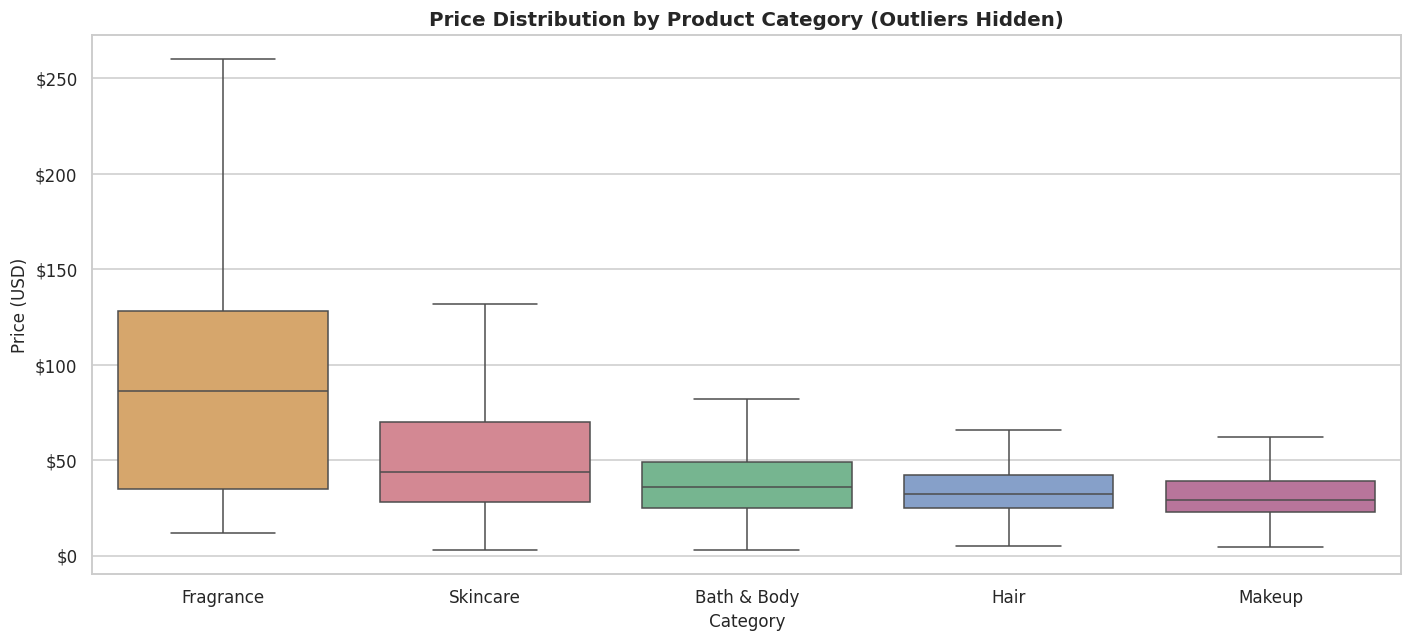

Saved eda_01_price_by_category.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
focus_cats = df[df['primary_category'].isin(FOCUS_CATEGORIES + ['Fragrance'])]
cat_order  = (focus_cats.groupby('primary_category')['price_usd']
                         .median().sort_values(ascending=False).index)
sns.boxplot(data=focus_cats, x='primary_category', y='price_usd',
            order=cat_order, palette=CATEGORY_PALETTE, showfliers=False, ax=ax)
ax.set_title('Price Distribution by Product Category (Outliers Hidden)', fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout(); plt.savefig('eda_01_price_by_category.png', bbox_inches='tight')
plt.show(); print('Saved eda_01_price_by_category.png')

## 7.2 Price Tier Counts - Stacked Bar

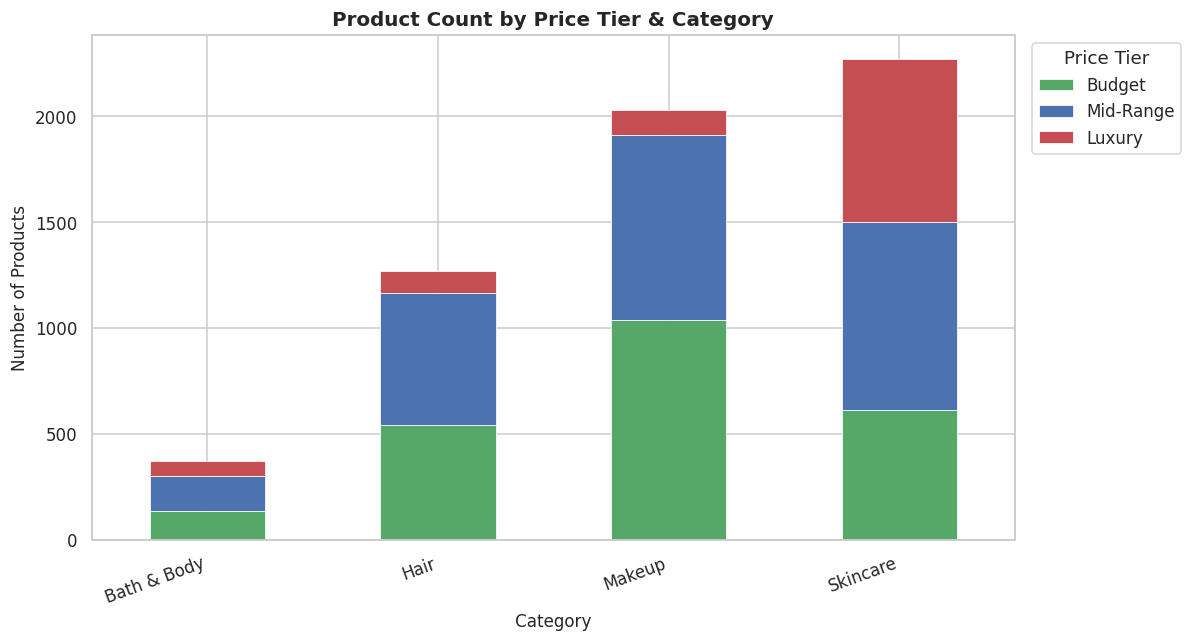

Saved eda_02_price_tier_stacked.png


In [11]:
tier_cat = (df[df['primary_category'].isin(FOCUS_CATEGORIES)]
              .groupby(['primary_category', 'price_tier'])
              .size().unstack(fill_value=0)
              .reindex(columns=['Budget', 'Mid-Range', 'Luxury'], fill_value=0))
fig, ax = plt.subplots(figsize=(11, 6))
tier_cat.plot(kind='bar', stacked=True, ax=ax,
              color=['#55A868', '#4C72B0', '#C44E52'], edgecolor='white', linewidth=0.5)
ax.set_title('Product Count by Price Tier & Category', fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Number of Products')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Price Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.savefig('eda_02_price_tier_stacked.png', bbox_inches='tight')
plt.show(); print('Saved eda_02_price_tier_stacked.png')

## 7.3 Price vs Rating — Does expensive = better?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price vs. Rating: Does Expensive = Better?', fontsize=14, fontweight='bold')
for ax, cat in zip(axes, ['Skincare', 'Makeup']):
    sub    = df_focus[df_focus['primary_category'] == cat]
    sample = sub.sample(min(400, len(sub)), random_state=42)
    color  = CATEGORY_PALETTE.get(cat, '#888')
    ax.scatter(sample['price_usd'], sample['rating'],
               color=color, alpha=0.4, s=20, edgecolors='none')
    mask  = ~sample['rating'].isna()
    coefs = np.polyfit(sample.loc[mask, 'price_usd'], sample.loc[mask, 'rating'], 1)
    x_l   = np.linspace(sample['price_usd'].min(), sample['price_usd'].max(), 100)
    ax.plot(x_l, np.polyval(coefs, x_l), 'k--', linewidth=1.5,
            label=f'slope={coefs[0]:.4f}')
    corr = sample['price_usd'].corr(sample['rating'])
    ax.set_title(f'{cat}   (r = {corr:.3f})', color=color, fontweight='bold')
    ax.set_xlabel('Price (USD)'); ax.set_ylabel('Rating (1-5)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('eda_03_price_vs_rating.png', bbox_inches='tight')
plt.show(); print('Saved eda_03_price_vs_rating.png')

## 7.4 Correlation Heatmap

In [ ]:
heatmap_cols = ['price_usd', 'rating', 'ingredient_count',
                'price_per_ingredient', 'luxury_markup_index']
corr_mat = df_focus[heatmap_cols].corr()
fig, ax  = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_mat, mask=np.triu(np.ones_like(corr_mat, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (Focus Categories)', fontweight='bold')
plt.tight_layout(); plt.savefig('eda_04_correlation_heatmap.png', bbox_inches='tight')
plt.show(); print('Saved eda_04_correlation_heatmap.png')

## 7.5 Price-per-Ingredient by Category & Tier

In [ ]:
ppi_cat = (df_focus.groupby(['primary_category', 'price_tier'])['price_per_ingredient']
                   .mean().reset_index())
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=ppi_cat, x='primary_category', y='price_per_ingredient',
            hue='price_tier', hue_order=['Budget', 'Mid-Range', 'Luxury'],
            palette={'Budget': '#55A868', 'Mid-Range': '#4C72B0', 'Luxury': '#C44E52'}, ax=ax)
ax.set_title('Avg Price-per-Ingredient by Category & Tier\n'
             '(Higher = More Markup per Ingredient)', fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Avg $ per Ingredient')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.2f}'))
plt.xticks(rotation=15, ha='right'); plt.tight_layout()
plt.savefig('eda_05_price_per_ingredient.png', bbox_inches='tight')
plt.show(); print('Saved eda_05_price_per_ingredient.png')

## 7.6 Ingredient Count Distribution: Luxury vs Budget

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ingredient Count: Luxury vs Budget Products', fontsize=14, fontweight='bold')
for ax, tier, color in zip(axes, ['Luxury', 'Budget'], ['#C44E52', '#55A868']):
    sub = df_focus[df_focus['price_tier'] == tier]['ingredient_count'].dropna()
    ax.hist(sub, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(sub.mean(),   color='black', linestyle='--', label=f'Mean: {sub.mean():.1f}')
    ax.axvline(sub.median(), color='grey',  linestyle=':',  label=f'Median: {sub.median():.0f}')
    ax.set_title(f'{tier} Products', color=color, fontweight='bold')
    ax.set_xlabel('Ingredient Count'); ax.set_ylabel('Number of Products')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('eda_06_ingredient_count_hist.png', bbox_inches='tight')
plt.show(); print('Saved eda_06_ingredient_count_hist.png')

## 7.7 Top 15 Brands by Luxury Markup Index

In [ ]:
brand_markup = (df_focus[df_focus['price_tier'] == 'Luxury']
                .groupby('brand_name')['luxury_markup_index']
                .mean().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(brand_markup.index[::-1], brand_markup.values[::-1],
               color=sns.color_palette('Reds_r', len(brand_markup)))
ax.set_xlabel('Avg Luxury Markup Index (vs Category Median)')
ax.set_title('Top 15 Brands by Luxury Markup Index', fontweight='bold')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='Category median (1.0x)')
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}x', va='center', fontsize=8)
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('eda_07_brand_markup.png', bbox_inches='tight')
plt.show(); print('Saved eda_07_brand_markup.png')

## 7.8 Synonym Coverage Chart

In [ ]:
top_canonical = (synonyms_df.groupby('canonical_name').size()
                             .sort_values(ascending=False).head(20))
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_canonical.index[::-1], top_canonical.values[::-1],
        color=sns.color_palette('PuRd_r', 20))
ax.set_xlabel('Number of Raw Synonyms Mapped')
ax.set_title('Top 20 Canonical Ingredients by Synonym Count\n'
             '(loaded from chemical_synonyms.csv)', fontweight='bold')
for i, (val, name) in enumerate(zip(top_canonical.values[::-1], top_canonical.index[::-1])):
    ax.text(val + 0.05, i, str(int(val)), va='center', fontsize=8)
plt.tight_layout(); plt.savefig('eda_08_synonym_coverage.png', bbox_inches='tight')
plt.show(); print('Saved eda_08_synonym_coverage.png')

## 7.9 Luxury vs Budget Count by Category

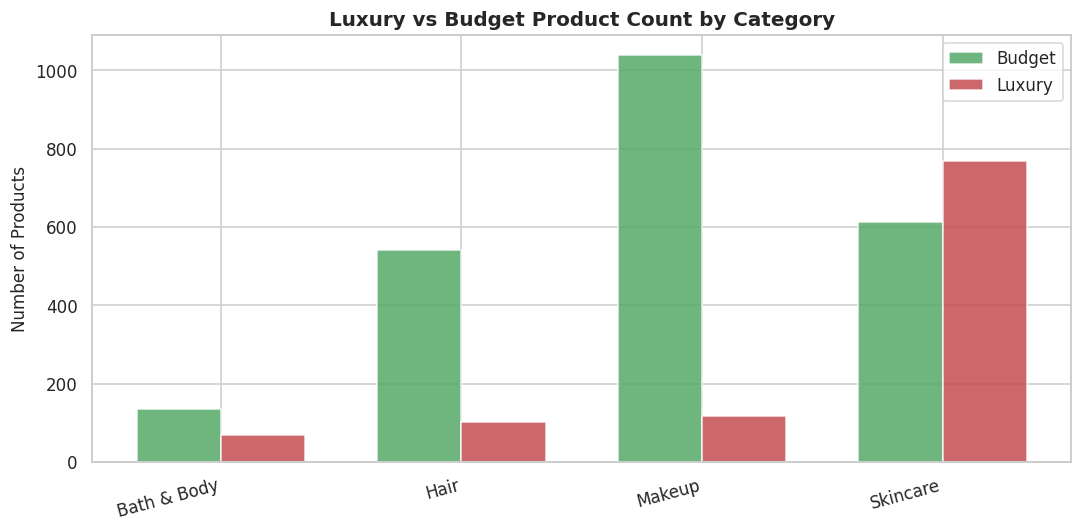

Saved eda_09_luxury_vs_budget_count.png


In [18]:
lux_bud = (df_focus[df_focus['price_tier'].isin(['Luxury', 'Budget'])]
             .groupby(['primary_category', 'price_tier'])
             .size().unstack(fill_value=0)
             .reindex(columns=['Budget', 'Luxury'], fill_value=0))
x = np.arange(len(lux_bud)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, lux_bud['Budget'], width, label='Budget',  color='#55A868', alpha=0.85)
ax.bar(x + width/2, lux_bud['Luxury'], width, label='Luxury',  color='#C44E52', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(lux_bud.index, rotation=15, ha='right')
ax.set_ylabel('Number of Products')
ax.set_title('Luxury vs Budget Product Count by Category', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('eda_09_luxury_vs_budget_count.png', bbox_inches='tight')
plt.show(); print('Saved eda_09_luxury_vs_budget_count.png')

## 8. JACCARD SIMILARITY — DUPE DETECTION ENGINE

In [19]:
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Compute Jaccard similarity between two canonical ingredient sets."""
    if not set_a or not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union        = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0
 
 
def find_dupes_for_category(category: str,
                            df_cat: pd.DataFrame,
                            sim_cutoff: float   = DUPE_SIM_CUTOFF,
                            budget_ratio: float = BUDGET_RATIO_MAX) -> list:
    """
    Cross-compare every Luxury vs Budget product in one category.
    Both filters must pass: Jaccard >= sim_cutoff AND price ratio <= budget_ratio.
    """
    luxury = df_cat[df_cat['price_tier'] == 'Luxury'].copy()
    budget = df_cat[df_cat['price_tier'] == 'Budget'].copy()
    if luxury.empty or budget.empty:
        return []
 
    results = []
    for _, lux_row in luxury.iterrows():
        lux_ings  = lux_row['canonical_ings']
        lux_price = lux_row['price_usd']
        for _, bud_row in budget.iterrows():
            bud_price = bud_row['price_usd']
            if lux_price == 0 or bud_price / lux_price > budget_ratio:
                continue
            sim = jaccard_similarity(lux_ings, bud_row['canonical_ings'])
            if sim >= sim_cutoff:
                results.append({
                    'category':      category,
                    'luxury_id':     lux_row['product_id'],
                    'luxury_name':   lux_row['product_name'],
                    'luxury_brand':  lux_row['brand_name'],
                    'luxury_price':  lux_price,
                    'luxury_rating': lux_row['rating'],
                    'luxury_ing_n':  len(lux_ings),
                    'budget_id':     bud_row['product_id'],
                    'budget_name':   bud_row['product_name'],
                    'budget_brand':  bud_row['brand_name'],
                    'budget_price':  bud_price,
                    'budget_rating': bud_row['rating'],
                    'budget_ing_n':  len(bud_row['canonical_ings']),
                    'jaccard_sim':   round(sim, 4),
                    'shared_ings':   sorted(list(lux_ings & bud_row['canonical_ings'])),
                    'price_saving':  round(lux_price - bud_price, 2),
                    'saving_pct':    round((lux_price - bud_price) / lux_price * 100, 1),
                })
    return results
 
 
print('\nRunning Jaccard dupe detection...')
all_dupes  = []
dupe_stats = {}
 
for cat in FOCUS_CATEGORIES:
    df_cat = df_focus[df_focus['primary_category'] == cat].copy()
    dupes  = find_dupes_for_category(cat, df_cat)
    all_dupes.extend(dupes)
    lux_n  = int((df_cat['price_tier'] == 'Luxury').sum())
    bud_n  = int((df_cat['price_tier'] == 'Budget').sum())
    dupe_stats[cat] = {
        'luxury_products':         lux_n,
        'budget_products':         bud_n,
        'dupe_pairs':              len(dupes),
        'unique_luxury_with_dupe': len({d['luxury_id'] for d in dupes}),
    }
    print(f'  {cat:12s}  Luxury={lux_n:4d}  Budget={bud_n:4d}  '
          f'Pairs={len(dupes):4d}  Luxury w/ dupe={dupe_stats[cat]["unique_luxury_with_dupe"]:4d}')
 
dupes_df = pd.DataFrame(all_dupes)
print(f'\nTotal dupe pairs: {len(dupes_df):,}')
if not dupes_df.empty:
    dupes_df.to_csv('dupe_results.csv', index=False)
    print('Saved dupe_results.csv')


Running Jaccard dupe detection...
  Skincare      Luxury= 769  Budget= 614  Pairs=  15  Luxury w/ dupe=  15
  Makeup        Luxury= 118  Budget=1039  Pairs=   0  Luxury w/ dupe=   0
  Hair          Luxury= 102  Budget= 542  Pairs=   4  Luxury w/ dupe=   4
  Bath & Body   Luxury=  69  Budget= 135  Pairs=   3  Luxury w/ dupe=   3

Total dupe pairs: 22
Saved dupe_results.csv


## 9. VALUE SCORE COMPUTATION & DUPE RANKING

In [ ]:
# Value Score = Jaccard * 0.50 + norm_saving_pct * 0.30 + (budget_rating/5) * 0.20
 
if not dupes_df.empty:
    dupes_df['norm_saving'] = dupes_df['saving_pct'] / dupes_df['saving_pct'].max()
    dupes_df['value_score'] = (
        dupes_df['jaccard_sim']        * 0.50 +
        dupes_df['norm_saving']        * 0.30 +
        (dupes_df['budget_rating'] / 5) * 0.20
    ).round(4)
    dupes_df = dupes_df.sort_values('value_score', ascending=False).reset_index(drop=True)
    dupes_df.to_csv('dupe_results_scored.csv', index=False)
    print('Value Score computed -> dupe_results_scored.csv')
 
    # Value Score Distribution
    fig, ax = plt.subplots(figsize=(11, 5))
    for cat in FOCUS_CATEGORIES:
        sub = dupes_df[dupes_df['category'] == cat]['value_score'].dropna()
        if not sub.empty:
            sub.hist(ax=ax, bins=20, alpha=0.55,
                     label=f'{cat} (n={len(sub)})',
                     color=CATEGORY_PALETTE.get(cat, '#888'))
    ax.set_xlabel('Value Score (0-1)'); ax.set_ylabel('Frequency')
    ax.set_title('Value Score Distribution of Dupe Pairs', fontweight='bold')
    ax.legend(); plt.tight_layout()
    plt.savefig('eda_10_value_score_dist.png', bbox_inches='tight')
    plt.show(); print('Saved eda_10_value_score_dist.png')
 
    # Top 20 Dupes
    top20 = dupes_df.head(20).copy()
    top20['label'] = top20['budget_name'].str[:22] + '\nvs\n' + top20['luxury_name'].str[:22]
    fig, ax = plt.subplots(figsize=(10, 9))
    colors  = [CATEGORY_PALETTE.get(c, '#888') for c in top20['category']]
    bars    = ax.barh(top20['label'][::-1], top20['value_score'][::-1],
                      color=colors[::-1], alpha=0.85)
    ax.set_xlabel('Value Score'); ax.set_xlim(0, 1.10)
    ax.set_title('Top 20 Dupe Pairs by Value Score', fontweight='bold')
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.3f}', va='center', fontsize=7)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=CATEGORY_PALETTE[c], label=c)
                        for c in FOCUS_CATEGORIES if c in CATEGORY_PALETTE],
              loc='lower right', fontsize=8)
    plt.tight_layout(); plt.savefig('eda_11_top20_dupes.png', bbox_inches='tight')
    plt.show(); print('Saved eda_11_top20_dupes.png')
 
    # Similarity vs Saving Scatter
    fig, ax = plt.subplots(figsize=(11, 6))
    for cat in FOCUS_CATEGORIES:
        sub = dupes_df[dupes_df['category'] == cat]
        ax.scatter(sub['jaccard_sim'], sub['price_saving'],
                   color=CATEGORY_PALETTE.get(cat, '#888'), alpha=0.5, s=18, label=cat)
    ax.axvline(DUPE_SIM_CUTOFF, color='red', linestyle='--', linewidth=1.2,
               label=f'Sim cutoff = {DUPE_SIM_CUTOFF}')
    ax.set_xlabel('Jaccard Similarity'); ax.set_ylabel('Price Saving ($)')
    ax.set_title('Ingredient Similarity vs Price Saving', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.legend(fontsize=9); plt.tight_layout()
    plt.savefig('eda_12_sim_vs_saving.png', bbox_inches='tight')
    plt.show(); print('Saved eda_12_sim_vs_saving.png')
 
 


## 10. RESULTS VALIDATION & SUCCESS METRICS

In [21]:
print('\n' + '=' * 60)
print('  PROJECT SUCCESS METRICS')
print('=' * 60)
 
if not dupes_df.empty:
    total_luxury = {cat: dupe_stats[cat]['luxury_products']         for cat in FOCUS_CATEGORIES}
    lux_w_dupe   = {cat: dupe_stats[cat]['unique_luxury_with_dupe'] for cat in FOCUS_CATEGORIES}
    overall_pct  = sum(lux_w_dupe.values()) / sum(total_luxury.values()) * 100
 
    print(f'\n  Target: budget dupe for >= 70% of luxury products  (sim >= {DUPE_SIM_CUTOFF})\n')
    for cat in FOCUS_CATEGORIES:
        pct = lux_w_dupe[cat] / total_luxury[cat] * 100 if total_luxury[cat] > 0 else 0
        print(f'  {"OK" if pct>=70 else "--"}  {cat:12s}: '
              f'{lux_w_dupe[cat]:3d}/{total_luxury[cat]:3d} = {pct:.1f}%')
 
    print(f'\n  Overall coverage  : {sum(lux_w_dupe.values()):,}/{sum(total_luxury.values()):,} = {overall_pct:.1f}%')
    print(f'  Cleanliness Rate  : {cleanliness_rate:.1f}%  (tokens mapped via CSV)')
    print(f'  CSV entries used  : {len(CHEMICAL_DICTIONARY):,}')
 
    print('\n  TOP 5 DUPE PAIRS (by Value Score):')
    print('  ' + '-' * 56)
    for i, row in dupes_df.head(5).iterrows():
        print(f'  #{i+1}  [{row["category"]}]')
        print(f'       Luxury : {row["luxury_name"][:42]} -- ${row["luxury_price"]:.0f}')
        print(f'       Budget : {row["budget_name"][:42]} -- ${row["budget_price"]:.0f}')
        print(f'       Sim: {row["jaccard_sim"]*100:.1f}%  |  Save: ${row["price_saving"]:.0f} '
              f'({row["saving_pct"]:.0f}%)  |  Value: {row["value_score"]:.3f}')
        print()
 
    # Price-per-ingredient markup table
    ppi = (df_focus[df_focus['price_tier'].isin(['Luxury','Budget'])]
           .groupby(['primary_category','price_tier'])['price_per_ingredient']
           .mean().unstack().round(3))
    if 'Luxury' in ppi.columns and 'Budget' in ppi.columns:
        ppi['markup_ratio'] = (ppi['Luxury'] / ppi['Budget']).round(2)
        print('\n  PRICE-PER-INGREDIENT MARKUP (Luxury vs Budget):')
        print(ppi[['Budget','Luxury','markup_ratio']].to_string())
    print('\n' + '=' * 60)


  PROJECT SUCCESS METRICS

  Target: budget dupe for >= 70% of luxury products  (sim >= 0.6)

  --  Skincare    :  15/769 = 2.0%
  --  Makeup      :   0/118 = 0.0%
  --  Hair        :   4/102 = 3.9%
  --  Bath & Body :   3/ 69 = 4.3%

  Overall coverage  : 22/1,058 = 2.1%
  Cleanliness Rate  : 50.3%  (tokens mapped via CSV)
  CSV entries used  : 355

  TOP 5 DUPE PAIRS (by Value Score):
  --------------------------------------------------------
  #1  [Skincare]
       Luxury : Advanced Night Repair Synchronized Multi-R -- $195
       Budget : Mini Advanced Night Repair Synchronized Mu -- $19
       Sim: 100.0%  |  Save: $176 (90%)  |  Value: 0.955

  #2  [Hair]
       Luxury : Detox Shampoo & Refill Hair Set -- $72
       Budget : Mini Detox Shampoo -- $14
       Sim: 100.0%  |  Save: $58 (81%)  |  Value: 0.941

  #3  [Skincare]
       Luxury : TL Advanced  Tightening Neck Cream PLUS fo -- $95
       Budget : Mini TL Advanced  Tightening Neck Cream PL -- $15
       Sim: 100.0%  |  Sav

## 11. INTERACTIVE DUPE FINDER

In [ ]:
def find_dupes_for_product(luxury_product_id: str,
                           top_n: int        = 5,
                           sim_cutoff: float = 0.35,
                           max_budget: float = None) -> dict:
    """
    Find the best cheaper alternatives for a given luxury product_id.
    Uses canonical ingredient sets standardized via chemical_synonyms.csv.
    """
    match = df_focus[df_focus['product_id'] == luxury_product_id]
    if match.empty:
        print(f'Product ID "{luxury_product_id}" not found in focus dataset.')
        return {}
 
    lux_row   = match.iloc[0]
    lux_cat   = lux_row['primary_category']
    lux_ings  = lux_row['canonical_ings']
    lux_price = lux_row['price_usd']
 
    candidates = df_focus[
        (df_focus['primary_category'] == lux_cat) &
        (df_focus['product_id']       != luxury_product_id) &
        (df_focus['price_usd']         < lux_price)
    ].copy()
    if max_budget is not None:
        candidates = candidates[candidates['price_usd'] <= max_budget]
 
    candidates['sim'] = candidates['canonical_ings'].apply(
        lambda s: jaccard_similarity(lux_ings, s)
    )
    candidates = candidates[candidates['sim'] >= sim_cutoff]
    candidates = candidates.sort_values('sim', ascending=False).head(top_n)
 
    recommendations = [
        {
            'product_name': row['product_name'],
            'brand_name':   row['brand_name'],
            'price_usd':    row['price_usd'],
            'rating':       row['rating'],
            'similarity':   round(row['sim'] * 100, 1),
            'saving':       round(lux_price - row['price_usd'], 2),
            'saving_pct':   round((lux_price - row['price_usd']) / lux_price * 100, 1),
            'shared_ings':  sorted(list(lux_ings & row['canonical_ings']))[:10],
        }
        for _, row in candidates.iterrows()
    ]
 
    lux = {
        'product_id':   luxury_product_id,
        'product_name': lux_row['product_name'],
        'brand_name':   lux_row['brand_name'],
        'price_usd':    lux_price,
        'rating':       lux_row['rating'],
        'category':     lux_cat,
        'ing_count':    len(lux_ings),
    }
    print('=' * 65)
    print('  BEAUTY-BUDGET DISCOVERY ENGINE -- DUPE FINDER')
    print('=' * 65)
    print(f'  Luxury  : {lux["product_name"]}')
    print(f'  Brand   : {lux["brand_name"]}')
    print(f'  Category: {lux["category"]}   Price: ${lux["price_usd"]:.2f}   '
          f'Rating: {lux["rating"]:.2f}')
    print(f'  Ingredients: {lux["ing_count"]} (standardized via chemical_synonyms.csv)')
    print('-' * 65)
    if not recommendations:
        print(f'  No alternatives found above {sim_cutoff*100:.0f}% similarity.')
    else:
        for rank, rec in enumerate(recommendations, 1):
            print(f'  #{rank}  {rec["product_name"][:48]}')
            print(f'      Brand     : {rec["brand_name"]}')
            print(f'      Price     : ${rec["price_usd"]:.2f}  '
                  f'(save ${rec["saving"]:.2f} / {rec["saving_pct"]:.0f}%)')
            print(f'      Rating    : {rec["rating"]:.2f}')
            print(f'      Similarity: {rec["similarity"]:.1f}% overlap')
            print(f'      Shared    : {", ".join(rec["shared_ings"][:5])}...')
            print()
    print('=' * 65)
 
    if recommendations:
        fig, ax = plt.subplots(figsize=(9, 4))
        names   = [f'#{i+1} {r["product_name"][:30]}' for i, r in enumerate(recommendations)]
        scores  = [r['similarity'] for r in recommendations]
        colors  = plt.cm.Greens([s/100 for s in scores])
        bars    = ax.barh(names[::-1], scores[::-1], color=colors[::-1])
        ax.axvline(sim_cutoff * 100, color='red', linestyle='--',
                   linewidth=1.2, label=f'Cutoff ({sim_cutoff*100:.0f}%)')
        ax.set_xlabel('Jaccard Similarity (%)')
        ax.set_title(f'Alternatives for: {lux["product_name"][:45]}\n'
                     f'(${lux["price_usd"]:.0f} | ingredients via CSV)', fontweight='bold')
        ax.set_xlim(0, 110)
        for bar, price, score in zip(bars,
                                     [r['price_usd'] for r in recommendations[::-1]],
                                     scores[::-1]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'${price:.0f} | {score:.1f}%', va='center', fontsize=8)
        ax.legend(fontsize=9); plt.tight_layout()
        plt.savefig('dupe_finder_result.png', bbox_inches='tight')
        plt.show()
 
    return {'luxury_product': lux, 'recommendations': recommendations}
 
 
# --- Example queries ---
most_expensive = {
    cat: df_focus[df_focus['primary_category'] == cat]
         .sort_values('price_usd', ascending=False).iloc[0]
    for cat in ['Skincare', 'Makeup', 'Hair']
}
 
print('\n--- Example 1: Most Expensive Skincare Product ---')
find_dupes_for_product(most_expensive['Skincare']['product_id'], top_n=5, sim_cutoff=0.35)
 
print('\n--- Example 2: Most Expensive Makeup Product ---')
find_dupes_for_product(most_expensive['Makeup']['product_id'], top_n=5, sim_cutoff=0.35)
 
print('\n--- Example 3: Most Expensive Hair Product (budget cap $25) ---')
find_dupes_for_product(most_expensive['Hair']['product_id'], top_n=5, sim_cutoff=0.30, max_budget=25)

## Summary Table 

In [24]:
if not dupes_df.empty:
    summary_rows = []
    for cat in FOCUS_CATEGORIES:
        sub = dupes_df[dupes_df['category'] == cat]
        summary_rows.append({
            'Category':        cat,
            'Luxury Products': dupe_stats[cat]['luxury_products'],
            'Budget Products': dupe_stats[cat]['budget_products'],
            'Dupe Pairs':      dupe_stats[cat]['dupe_pairs'],
            'Luxury w/ Dupe':  lux_w_dupe.get(cat, 0),
            'Coverage %':      round(lux_w_dupe.get(cat,0) / dupe_stats[cat]['luxury_products'] * 100, 1),
            'Avg Jaccard':     round(sub['jaccard_sim'].mean(), 3) if not sub.empty else 0,
            'Avg Saving $':    round(sub['price_saving'].mean(), 2) if not sub.empty else 0,
            'Avg Value Score': round(sub['value_score'].mean(), 3)  if not sub.empty else 0,
        })
    pd.DataFrame(summary_rows).to_csv('project_summary.+csv', index=False)
    print('\nProject summary saved -> project_summary.csv')
 
print('\n\n  Beauty-Budget Discovery Engine -- Pipeline Complete.')
print('=' * 60)
print('  Output files:')
print('    chemical_synonyms.csv        <- synonym dataset (data, not code)')
print('    beauty_budget.db             <- SQLite products table')
print('    ingredient_docs.json         <- MongoDB-style ingredient docs')
print('    dupe_results.csv             <- qualifying dupe pairs')
print('    dupe_results_scored.csv      <- pairs ranked by Value Score')
print('    project_summary.csv          <- per-category success metrics')
print('    eda_01 ... eda_12 .png       <- EDA visualisations')
print('    dupe_finder_result.png       <- interactive finder output')
print('=' * 60)


Project summary saved -> project_summary.csv


  Beauty-Budget Discovery Engine -- Pipeline Complete.
  Output files:
    chemical_synonyms.csv        <- synonym dataset (data, not code)
    beauty_budget.db             <- SQLite products table
    ingredient_docs.json         <- MongoDB-style ingredient docs
    dupe_results.csv             <- qualifying dupe pairs
    dupe_results_scored.csv      <- pairs ranked by Value Score
    project_summary.csv          <- per-category success metrics
    eda_01 ... eda_12 .png       <- EDA visualisations
    dupe_finder_result.png       <- interactive finder output
